In [16]:
import pandas as pd
import numpy as np
import string
import re
import matplotlib.pyplot as plt
import seaborn as sns


import warnings as w
w.filterwarnings('ignore')


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report



import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [4]:
df = pd.read_csv(r"C:\Users\jagji\OneDrive\Desktop\ALL Data Sets\emails.csv")
df.head(3)

,Text,Spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1


In [4]:
df.shape

(5728, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Text    5728 non-null   str  
 1   Spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 8.6 MB


# Clean the data

In [5]:
# check duplicate values
df.duplicated().sum()

np.int64(33)

In [6]:
# drop duplicates
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# check the data is balance or not
df['Spam'].value_counts()

Spam
0    4327
1    1368
Name: count, dtype: int64

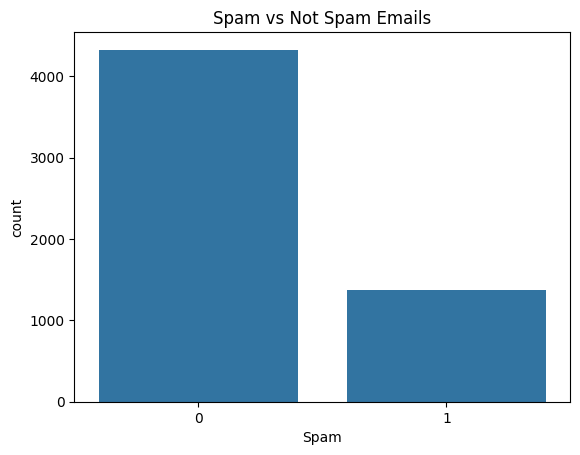

In [8]:
sns.countplot(x='Spam', data=df)
plt.title("Spam vs Not Spam Emails")
plt.show()

In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def clean_email(text):

    # convert to lowercase
    text = text.lower() 

    # Remove subject word from sentence
    text = re.sub(r'^subject[:\s]+', '', text)
    
     # join spaced words like "f r e e" -> "free"
    text = re.sub(r'\b(?:\w\s){2,}\w\b', lambda x: x.group().replace(" ", ""), text)

     # replace numbers with token
    text = re.sub(r'\d+', ' numtoken ', text)

     # remove html tags
    text = re.sub(r'<.*?>', '', text)

     # remove urls
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # remove repeated characters (loooove -> loove)
    text = re.sub(r'(.)\1{2,}', r'\1', text)



   # remove newline and tabs
    text = text.replace('\n', ' ').replace('\t', ' ')

    
    
    # remove emojis
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    # .str.translate() applies a translation operation to every string in the 'Text' column
    # str.maketrans() creates a translation table used by translate()
    # First argument: characters to replace (empty → no replacement)
    # Second argument: characters to replace with (empty → nothing to replace)
    # Third argument: characters to DELETE from the text
    # string.punctuation contains all punctuation marks. Example: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


    text = re.sub(r'\s+', ' ', text)  # remove multiple spaces
    
    text = text.strip()  # remove extra spaces

    # tokenization
    words = word_tokenize(text)

    # remove stopwords + apply lemmatization
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [23]:
models = {
    "MultinomialNB":MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "SVC": LinearSVC()
}



pipeline = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            stop_words='english',   # removes common words
            ngram_range=(1,2),      # captures phrases like free money
            max_df=0.9,             # removes overly common words
            min_df=3,               # removes rare noisy words
            sublinear_tf=True       # reduces the impact of words that appear many times in a document
        )
    ),

      ("model", MultinomialNB())  # placeholder

    
])

In [19]:
x = df['Text']
y = df['Spam']

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
# stratify = y - It make sure the ratio of classes in my training and testing sets is exactly the same as the ratio in the original dataset.

In [21]:
x_train_clean = [clean_email(text) for text in x_train]
x_test_clean = [clean_email(text) for text in x_test]

In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipeline.set_params(model=model)

    scores = cross_val_score(pipeline,x_train_clean,y_train,cv=skf,scoring='f1')

    print(name, "F1 Score:", scores.mean())

MultinomialNB F1 Score: 0.8511973412191528
BernoulliNB F1 Score: 0.9774819174428357
SVC F1 Score: 0.9847444140744693


In [26]:
final_pipeline = Pipeline([


    (
        "tfidf",
        TfidfVectorizer(
            stop_words='english',   # removes common words
            ngram_range=(1,2),      # captures phrases like free money
            max_df=0.9,             # removes overly common words
            min_df=3,               # removes rare noisy words
            sublinear_tf=True       # reduces the impact of words that appear many times in a document
        )
    ),

      ("model", LinearSVC())  # Final Model

    
])

In [27]:
# Hyperparameter tuning of SVC Model using GridsearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1], 
              
    "model__loss": ["hinge", "squared_hinge"],

    "model__class_weight": [None, "balanced"]
}



grid = GridSearchCV(

    final_pipeline,                 
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",
    n_jobs=-1, # faster computation
    verbose=2 # shows detailed progress of each parameter combination and cross-validation fold during GridSearchCV training
)

grid.fit(x_train_clean, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...LinearSVC())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__loss': ['hinge', 'squared_hinge']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for e

In [28]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'model__C': 1, 'model__class_weight': 'balanced', 'model__loss': 'squared_hinge'}
Best CV Score: 0.9894567637152928


In [29]:
best_model = grid.best_estimator_
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [33]:
y_pred = best_model.predict(x_test_clean)

In [34]:
con_mat = confusion_matrix(y_test,y_pred)
con_mat

array([[862,   3],
       [  4, 270]])

In [35]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       865
           1       0.99      0.99      0.99       274

    accuracy                           0.99      1139
   macro avg       0.99      0.99      0.99      1139
weighted avg       0.99      0.99      0.99      1139



In [38]:
label_map = {
    0: "Not Spam Email",
    1: "Spam Email"
}

sample = "Congratulations! You won a lottery and you have to give bank details to get money"
cleaned = clean_email(sample)

pred = best_model.predict([cleaned])


for p in pred:
    print(label_map[p])

Spam Email


In [41]:
text = """Subject Project Meeting Rescheduled to Thursday

Hi Team,

The project review meeting originally scheduled for Wednesday has been moved to Thursday at 3:00 PM due to a scheduling conflict. Please make sure to update your calendars accordingly.

During the meeting, we will discuss the progress of the current sprint, review the pending tasks, and plan the next set of deliverables. If you have any updates or blockers, please be prepared to share them.

The meeting link will remain the same as the previous invite. Let me know if anyone is unable to attend.

Best regards,
Rahul
Project Coordinator
"""

cleaned_text = clean_email(text)

real_pred = best_model.predict([cleaned_text])
print(label_map[real_pred[0]])

Not Spam Email


In [42]:
import joblib

joblib.dump(best_model, "EmailSpam_Detection_model.pkl")

print("Model saved successfully")

Model saved successfully
